In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

In [ ]:
# Load the dataset using the pandas library function read_csv
data = pd.read_csv('e1_nutrients.csv')

In [ ]:
# Plot Data function to visualise the relationships between the nutrient concentrations and the depth variable, all plotted as scatter plots
def plot_data(data):
    nutrient_cols = [c for c in data.columns if c != "Depth"]
    plt.figure(figsize=(10, 6))
    for col in nutrient_cols:
        plt.scatter(data["Depth"], data[col], s=35, alpha=0.75, label=col)

    plt.xlabel("Depth")
    plt.ylabel("Concentration")
    plt.title("Scatter Plot of All Nutrient Data vs Depth")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_data(data)


In [ ]:
# Function used to plot the comparison between the original, unfiltered data, and the data after applying the filtering process
def plot_filter_comparison(unfiltered_data, filtered_data, variables_to_plot):
    # Create a 2x2 grid of subplots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    fig.suptitle('Impact of IQR Outlier Filtering by Depth', fontsize=18, fontweight='bold', y=0.98)

    # Loop through the variables to plot and create scatter plots for both unfiltered and filtered data
    for i, var in enumerate(variables_to_plot):
        row = i // 2
        col = i % 2
        ax = axes[row, col]
        
        # Scatter plot for unfiltered data
        ax.scatter(unfiltered_data['Depth'], unfiltered_data[var], 
                   c='tab:blue', alpha=0.6, s=30, label='Unfiltered Data')
        
        # Scatter plot for filtered data
        ax.scatter(filtered_data['Depth'], filtered_data[var], 
                   c='tab:orange', alpha=0.9, s=30, label='Filtered Data')
        
        # Set titles and labels
        ax.set_title(f'{var} vs Depth', fontsize=14, fontweight='bold')
        ax.set_xlabel('Depth (m)', fontsize=12)
        ax.set_ylabel('Concentration', fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.legend(loc='upper right')

    # Adjust layout to prevent overlap and show the plots
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

The above helper functions are used to provide visual comparisons by plotting the relevant data on sets of axis, using the python library MatplotLib, a standardised library for producing graphs and figures.

In [ ]:
# Function to filter out outliers based on the IQR method for a specific column
def filter_by_column(data, column_name):
    # Check if the inputted column exists in the provided data
    if column_name in data.columns:
        # Check if the required depth column exists in the provided data
        if "Depth" not in data.columns:
            # If the depth column does not exist, raise a ValueError with an appropriate message
            raise ValueError("Column 'Depth' does not exist in the Data.")
        
        # Directly copy the data to a new set without modifying the original data
        data_new = data.copy()

        # Sort the data, using the depth column to ensure that the quantile calculations are performed correctly for each depth level
        data_new = data_new.sort_values("Depth", kind="mergesort").reset_index(drop=True)

        # Calculate the first and third quartiles (Q1 and Q3) for the specified column, grouped by depth
        q1 = data_new.groupby("Depth")[column_name].quantile(0.25)
        q3 = data_new.groupby("Depth")[column_name].quantile(0.75)

        # Calculate the interquartile range (IQR) for the specified column, grouped by depth
        iqr = q3 - q1

        # Using the IQR, calculating the lower and upper bounds to detect outliers for the specified column, grouped by depth
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        # Using the pandas map function, apply the calculated lower and upper bounds to the original data based on the depth values, creating two new series that represent the lower and upper bounds for each row in the original data
        lower_mapped = data_new["Depth"].map(lower_bound)
        upper_mapped = data_new["Depth"].map(upper_bound)

        # Filter the original data to include only rows where the values in the specified column are within the calculated lower and upper bounds, grouped by depth
        filtered_data = data_new[
            (data_new[column_name] >= lower_mapped) & 
            (data_new[column_name] <= upper_mapped)
        ]
        
        # Reset the indexes of the filtered data to keep the sequential nature of the data intact after the outliers are removed
        filtered_data = filtered_data.reset_index(drop=True)
        
        # Return the filtered data, which contains only the rows where the values in the specified column are within the calculated bounds for each depth level
        return filtered_data
    
    # If the specified column does not exist in the provided data, raise a ValueError
    else:
        # If the column does not exist, raise a ValueError
        raise ValueError(f"Column '{column_name}' does not exist in the Data.")



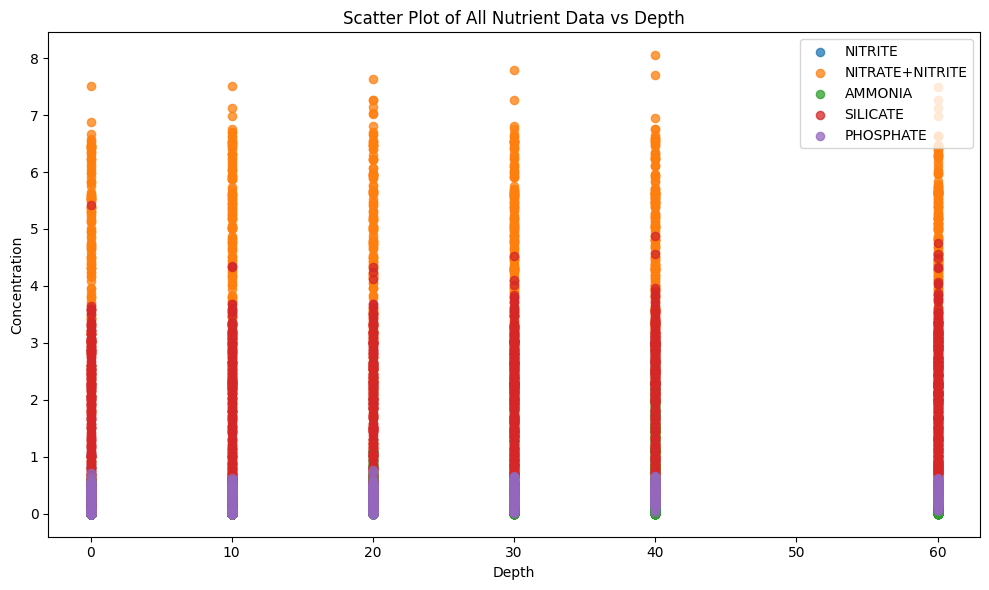

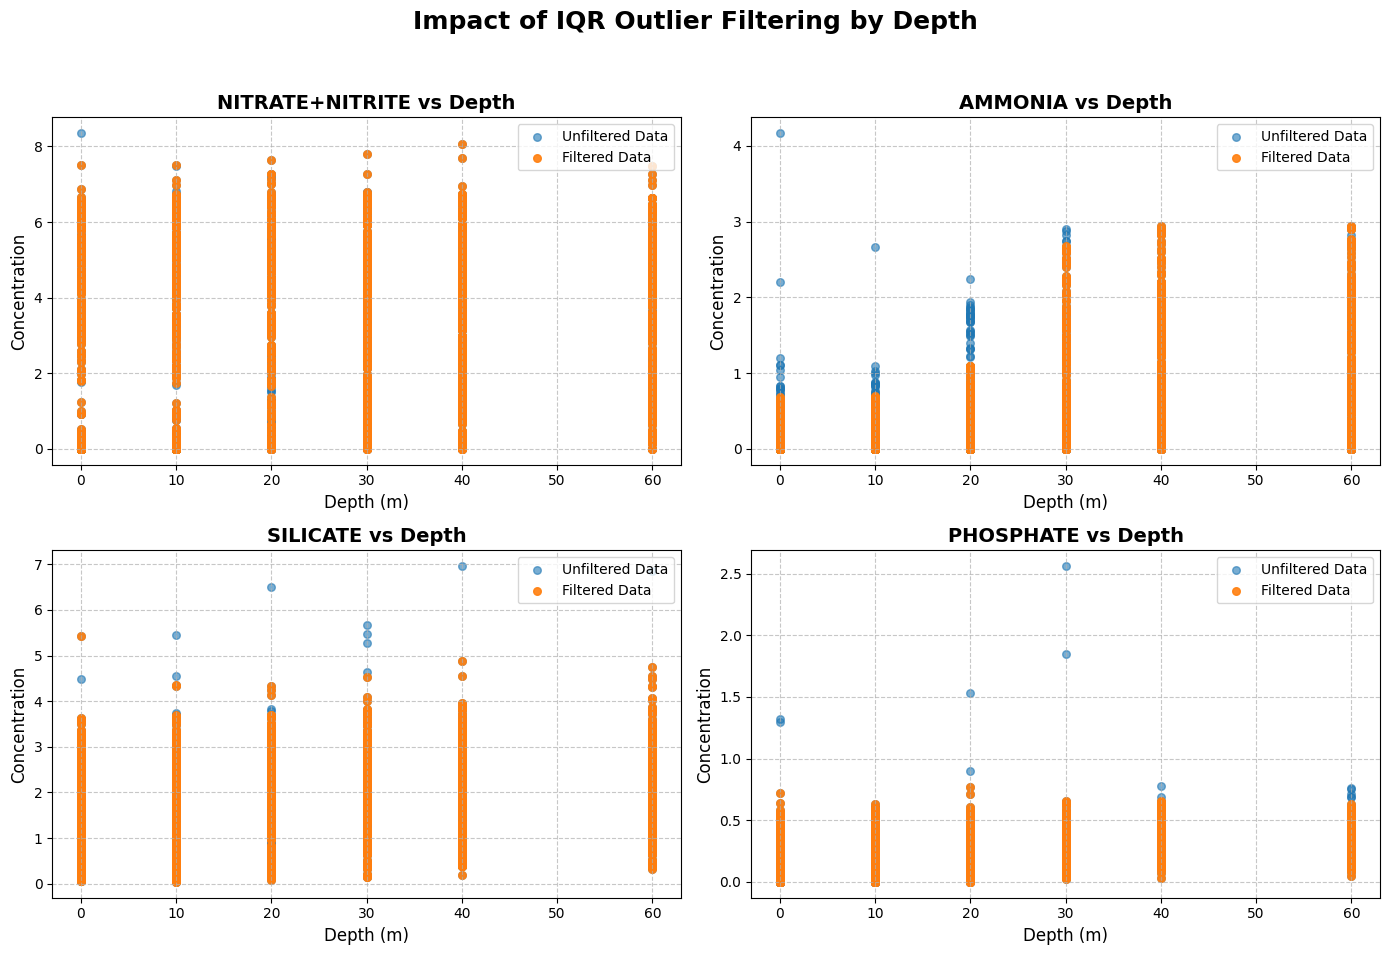

In [24]:
# Split the data into training and testing sets, using 80% of the data for training and 20% for testing
train_data, test_data = train_test_split(data, test_size=0.2, random_state=44)

# Define the columns that we want to apply the outlier filtering process to, and create a copy of the training data to apply the filtering process to
columns_to_clean = ['NITRATE+NITRITE', 'AMMONIA', 'SILICATE', 'PHOSPHATE']
clean_train_data = train_data.copy()

# Apply the outlier filtering process to each of the specified columns in the training data, using the filter_by_column function defined earlier, and update the copied clean_train_data with the filtered results after each iteration
for col in columns_to_clean:
    clean_train_data = filter_by_column(clean_train_data, col)

clean_train_data = clean_train_data.dropna().reset_index(drop=True)

# Plot the cleaned training data and the comparison between filtered and unfiltered data
plot_data(clean_train_data)
plot_filter_comparison(train_data, clean_train_data, columns_to_clean)

# Prepare the data for machine learning by separating the features (x) and the target variable (y), where the target variable is NITRITE, and then applying a RobustScaler to the data to scale it appropriately for machine learning algorithms
x_train = clean_train_data.drop('NITRITE', axis=1)
y_train = clean_train_data[['NITRITE']]

# Separate the features and target variable for the test data as well, and apply the same RobustScaler to the test data to ensure that it is scaled in the same way as the training data
x_test = test_data.drop('NITRITE', axis=1)
y_test = test_data[['NITRITE']]

# Initalise RobustScalar, and fit the scaler to the training data
scalar = RobustScaler()
y_scalar = RobustScaler()

# Fit the RobustScaler to the training data and transform both the training and test data using the fitted scaler, resulting in scaled versions of the data
x_train_scaled = scalar.fit_transform(x_train)
y_train_scaled = y_scalar.fit_transform(y_train).ravel()
x_test_scaled = scalar.transform(x_test)
y_test_scaled = y_scalar.transform(y_test).ravel()


The dataset has been loaded into a pandas dataframe. Considering that the dataset containes no missing values, no data dropping steps were required for ones with missing data. Before formatting and outlier handling was carried out, the dataset was split into 2 sets, a training set (80%) and a testing set (20%). If the entire dataset had been filtered or scaled together, the test data could have been inadvertently leaked into the model's training phase. By isolating this part of the dataset, it can remain a completely unseen set, for an accurate real world simulation. 

Extreme values were handles using the data's Interquartile Range (IQR). Because natural nutrient concentrations vary drastically depending on how deep the water is, a global outlier filter would have incorrectly deleted natural deep-water readings. To solve this issue, the Pandas groupby function was used to calculate Q1, Q3 and the 1.5x IQR boundaries for each depth measurement. This filter was applied exclusively to the predictor variables to prevent skewing the models. 

To ensure the data was in a suitable format for the Neural Network and Linear Regression models, the predictor variables needed to be scaled. RobustScaler was selected for this task over standard methods like MinMaxScaler or StandardScaler. Robust Scalar centres the data using the median and scales the data using the interquartile range. Furthermore, due to the decision not to filter the target data, the natural extremes in the target data have been retained, RobustScaler ensures that any remaining extreme numbers do not disproportionately skew the variance of the normal, everyday chemical readings.

In [42]:
# Initalise a Linear Regression model
lr_model = LinearRegression()

# Fit the model to the training data
lr_model.fit(x_train_scaled, y_train_scaled)

# Calculate the R^2 score for both the training and test data using the fitted Linear Regression model, and print the results
lr_score_train = lr_model.score(x_train_scaled, y_train_scaled)
lr_score_test = lr_model.score(x_test_scaled, y_test_scaled)
print(f"Linear Regression R^2 Score (train): {lr_score_train}, R^2 Score (test): {lr_score_test}")

# Initalise a Random Forest Regression Model
rf_model = RandomForestRegressor(random_state=44)

# Fit the model to the training data
rf_model.fit(x_train_scaled, y_train_scaled)

# Calculate the R^2 score for both the training and test data using the fitted Random Forest Regression model, and print the results
rf_score_train = rf_model.score(x_train_scaled, y_train_scaled)
rf_score_test = rf_model.score(x_test_scaled, y_test_scaled)
print(f"Random Forest R^2 Score (train): {rf_score_train}, R^2 Score (test): {rf_score_test}")

# Initalise a Neural Network Regression Model
nn_model = MLPRegressor(random_state=44, max_iter=2000)

# Fit the model to the training data
nn_model.fit(x_train_scaled, y_train_scaled)

# Calculate the R^2 score for both the training and test data using the fitted Neural Network Regression model, and print the results
nn_score_train = nn_model.score(x_train_scaled, y_train_scaled)
nn_score_test = nn_model.score(x_test_scaled, y_test_scaled)
print(f"Neural Network R^2 Score (train): {nn_score_train}, R^2 Score (test): {nn_score_test}")

# Taking a sample input from the test data, use all 3 models to predict the NITRITE value for the sample input, and print the actual value along with the predicted values from each model for comparison
sample_input = x_test_scaled[[0]]
actual_value = y_test_scaled[0]
actual_value_unscaled = y_test.iloc[0]

print(f"Actual NITRITE value: {actual_value_unscaled}")

print(f"Linear Regression predicted: {y_scalar.inverse_transform(lr_model.predict(sample_input).reshape(-1, 1))[0][0]}")
print(f"Random Forest predicted:     {y_scalar.inverse_transform(rf_model.predict(sample_input).reshape(-1, 1))[0][0]}")
print(f"Neural Network predicted:    {y_scalar.inverse_transform(nn_model.predict(sample_input).reshape(-1, 1))[0][0]}")

Linear Regression R^2 Score (train): 0.12708004335687917, R^2 Score (test): 0.12584859853151165
Random Forest R^2 Score (train): 0.9254744342825552, R^2 Score (test): 0.4706599052707454
Neural Network R^2 Score (train): 0.5322841385429653, R^2 Score (test): 0.2971502057122729
Actual NITRITE value: NITRITE    0.02
Name: 944, dtype: float64
Linear Regression predicted: 0.09870152221581278
Random Forest predicted:     0.028300000000000006
Neural Network predicted:    0.052438258355349945


In [41]:
# To evaluate the performance of the models, cross-validation can be used to calculate the mean squared error for each model across multiple folds of the training data
lr_mean_squared_error = -cross_val_score(lr_model, x_train_scaled, y_train_scaled, cv=5, scoring='neg_mean_squared_error')
rf_mean_squared_error = -cross_val_score(rf_model, x_train_scaled, y_train_scaled, cv=5, scoring='neg_mean_squared_error')
nn_mean_squared_error = -cross_val_score(nn_model, x_train_scaled, y_train_scaled, cv=5, scoring='neg_mean_squared_error')

print(lr_mean_squared_error, rf_mean_squared_error, nn_mean_squared_error)

# Print the mean squared error for each model across the 5 folds of the training data
print("LR mean squared error: ", lr_mean_squared_error.mean())
print("RF mean squared error: ", rf_mean_squared_error.mean())
print("NN mean squared error: ", nn_mean_squared_error.mean())

[0.72421447 0.86749757 2.59092817 3.74520983 4.49877986] [0.3156092  0.30701241 1.51191488 2.3005466  2.61844862] [0.35206301 0.45674026 1.97800531 2.6383631  3.46956849]
LR mean squared error:  2.485325980241914
RF mean squared error:  1.4107063411406588
NN mean squared error:  1.7789480333927892


/var/folders/27/hllxnbt92kl714nh0x9tfy400000gn/T/ipykernel_13930/2725467226.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([lr_mean_squared_error, rf_mean_squared_error, nn_mean_squared_error], labels=['Linear Regression', 'Random Forest', 'Neural Network'])


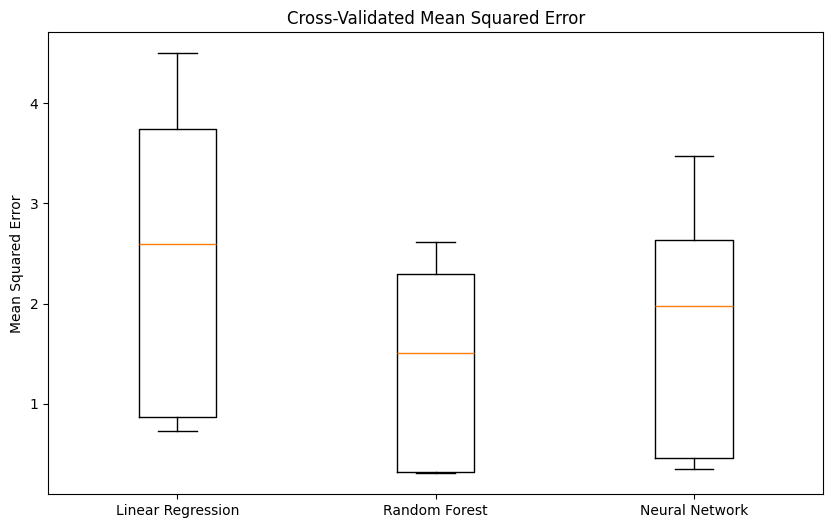

In [43]:
# Using a box plot allows for a direct comparison of mean squared errors across the different models
plt.figure(figsize=(10, 6))
plt.boxplot([lr_mean_squared_error, rf_mean_squared_error, nn_mean_squared_error], labels=['Linear Regression', 'Random Forest', 'Neural Network'])
plt.ylabel('Mean Squared Error')
plt.title('Cross-Validated Mean Squared Error')

# Show the box plot to visualize the distribution of mean squared errors for each model across the 5 folds of the training data
plt.show()

Prior to the tuning of model's parameters, the three regression models were evaluated using a round of 5 fold cross validation to establish a baseline assessment of performance and predictive stability. The mean squared error results, which have been plotted above on the box plot, compare how the different algorithms map the complex, non - linear realationships found in the provided dataset. 

The random forest model demonstrated the strongest untuned performance, providing both the lowest median error and the smallest variance across the validation folds. 

The neural network model performed moderately well as a baseline, achieving a lower median error and varience than the linear model, but still fell short to the random forest model. 

On the other hand, the linear regression model proved to be the weakest baseline predictor. It showed the highest median error and the widest variance, indicating that a simple linear algorithm struggles to accurately map the underlying non-linear dynamics of how ocean depth affects nutrient concentration.

Given the baseline results, manual parameter tuning has been undertaken by evaluating changes to parameters for both models. As demonstrated in the module's labs tuning has been carried out using a iterative structure, systematically evaluating parameter configurations and logging the relevant R^2 scores. 

For the random forest regression model, the n_estimators parameter was tuned by evaluating forest sizes between 10 and 250 trees, with the objective to identify the optimal balance between computational efficiency and accuracy. 

For the neural network model, various hidden layer sizes were tested, ranging from single layer to dual layer architectures, to determine the ideal network depth required to map the dataset without overfitting the training data.

Original R^2 score with default n_trees: 0.4706599052707454
Best RF score: 0.4794017117452478 with n_trees: 200


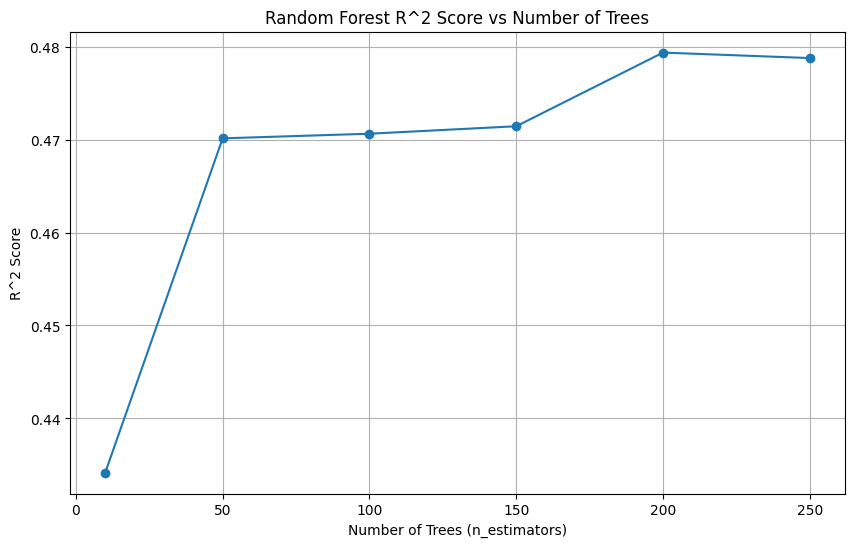

In [45]:
n_trees_options = [10,50,100,150,200,250]
forest_scores = []
best_score = float('-inf')
best_n_trees = None

for n in n_trees_options:
    forest_model = RandomForestRegressor(n_estimators=n, random_state=44)
    forest_model.fit(x_train_scaled, y_train_scaled)

    score = forest_model.score(x_test_scaled, y_test_scaled)
    forest_scores.append(score)

    if score > best_score:
        best_score = score
        best_n_trees = n

print(f"Original R^2 score with default n_trees: {rf_score_test}")
print(f"Best RF score: {best_score} with n_trees: {best_n_trees}")

plt.figure(figsize=(10, 6))
plt.plot(n_trees_options, forest_scores, marker='o')
plt.title('Random Forest R^2 Score vs Number of Trees')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('R^2 Score')
plt.grid()
plt.show()


As visualised above in the line graph, increasing the the number of trees initially provided a steep increase in model accuracy. However, the model quickly reached a point of diminishing returns, providing the best R^2 score at 200 trees. This configuration sucessfully raised the models score from its baseline around 0.4818 to 0.48320. 

Original R^2 score with default layer size: 0.2971502057122729
Best NN score: 0.307716888810293 with layer size: (100, 50)


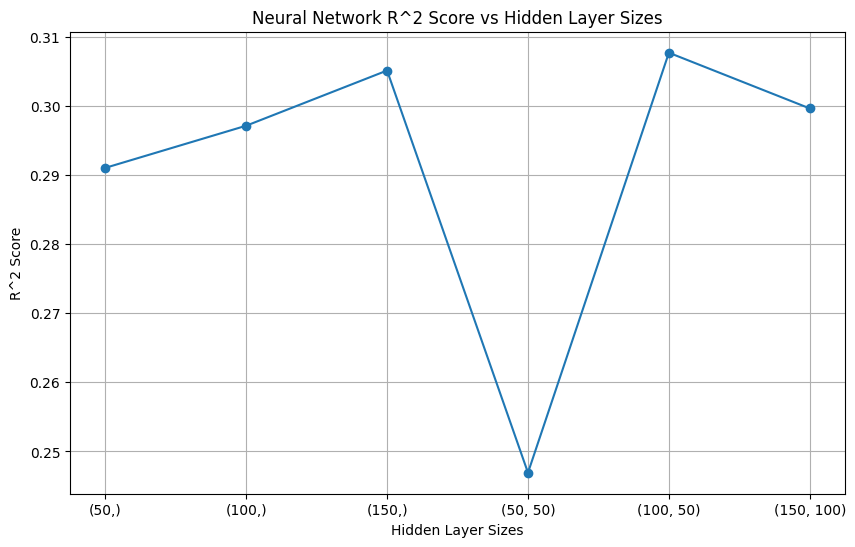

In [47]:
sizes_layer_options = [(50,), (100,), (150,), (50, 50), (100, 50), (150, 100)]
nn_scores = []
best_score = float('-inf')
best_layer_size = None

for size in sizes_layer_options:
    nm_model = MLPRegressor(random_state=44, max_iter=1000, hidden_layer_sizes=size)
    nm_model.fit(x_train_scaled, y_train_scaled)

    score = nm_model.score(x_test_scaled, y_test_scaled)
    nn_scores.append(score)

    if score > best_score:
        best_score = score
        best_layer_size = size

print(f"Original R^2 score with default layer size: {nn_score_test}")
print(f"Best NN score: {best_score} with layer size: {best_layer_size}")

plt.figure(figsize=(10, 6))
plt.plot([str(size) for size in sizes_layer_options], nn_scores, marker='o')
plt.title('Neural Network R^2 Score vs Hidden Layer Sizes')
plt.xlabel('Hidden Layer Sizes')
plt.ylabel('R^2 Score')
plt.grid()
plt.show()

## Task 2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Define the McCormick function, in order to generate the required values
def mccormick_function(s_array):
    x = s_array[0]
    y = s_array[1]
    fitness_score = np.sin(x+y) + (x-y)**2 - 1.5*x + 2.5*y + 1
    return fitness_score

In [ ]:
# Set the number of required solutions to 500
num_required_solutions = 500

# Set the dimensionality of the problem to 2, as the McCormick function is defined for two variables (x and y)
D = 2

# Generate random solutions within the specified bounds of -5 to 5 for both x and y, creating an array of shape (num_required_solutions, D) where each row represents a solution with two variables (x and y)
rad_solutions = np.random.uniform(-5,5, (num_required_solutions, D))

# Initialize an empty list to store the fitness scores for each solution generated
fitness_scores = []

# Iterate through each solution in the generated random solutions, calculate the fitness score using the McCormick function for each solution, and append the calculated fitness score to the list
for solution in rad_solutions:
    fitness = mccormick_function(solution)
    fitness_scores.append(fitness)

In [ ]:
# Create a scatter plot of the random solutions, where the x and y coordinates correspond to the two variables of the solutions, and the color of each point represents the fitness score calculated for that solution using the McCormick function
plt.figure(figsize=(10, 6))
plt.scatter(rad_solutions[:, 0], rad_solutions[:, 1], c=fitness_scores, cmap='viridis', s=50)
plt.colorbar(label='Fitness Score')
plt.title('Random Solutions Colored by Fitness Score')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [ ]:
class GMutation:
    def __init__(self,mutation_step_size):
        self.mutation_step_size = mutation_step_size

    def mutate(self, solution):
        solution_copy = solution.copy()
        solution_copy += np.random.normal(loc=0.0, scale=self.mutation_step_size, size=solution_copy.shape)
        return solution_copy
    
def evolve(x, y, function, mutation, compare, A):
    xp = mutation.mutate(x)
    yp = function(xp)

    if not compare(y , yp) :
        x = xp
        y = yp

    A.append(y)
    return x,y,A

def lessOrEqual(a, b):
    return a <= b

def optimise(D, function, mutation, ngens, compare):
    x = np.random.uniform(-5, 5, D)
    y = function(x)
    archive = []

    for gen in range(ngens):
        x, y, archive = evolve(x, y, function, mutation, compare, archive)

    return x,y,archive



mutation = GMutation(mutation_step_size=0.5)
best_sol, best_fit, fitness_history = optimise(D=2, function=mccormick_function, mutation=mutation, ngens=100, compare=lessOrEqual)

print(f"Best solution: {best_sol}, Best fitness: {best_fit}")

plt.figure(figsize=(8, 5))
plt.plot(fitness_history)
plt.title('Hill Climber: Fitness over Time')
plt.ylabel('Fitness Score (Minimisation)')
plt.show()